In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

`Explanation:` The above code sets up a Python environment for machine learning tasks, specifically for regression analysis. It does the following:
1. Imports necessary libraries:
   - numpy and pandas for data manipulation
   - matplotlib.pyplot for data visualization
   - Various machine learning tools from scikit-learn:
     - Metrics for evaluation
     - Linear and ensemble regression models
     - Data preprocessing tools
     - Model inspection utilities

2. Sets a random seed, (SEED = 42) and applies it to NumPy to ensure reproducible results.

3. Defines a helper function rmse() that calculates the Root Mean Squared Error between true values and predictions, which is a common metric for evaluating regression models.

This code establishes the foundation for a machine learning workflow, preparing the environment before any actual data is loaded or models are trained.

In [45]:
DATA_PATH = "data.xlsx"

def load_demand_data(path):
    # Read Excel with no header row
    df = pd.read_excel(path, header=None)

    # Keeping only first two columns and naming them timestamp and demand
    df = df.iloc[:, :2]
    df.columns = ["timestamp", "demand"]

    # Convert types
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["demand"] = pd.to_numeric(df["demand"], errors="coerce")

    # Drop invalid rows and sort
    df = df.dropna(subset=["timestamp", "demand"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    return df

raw = load_demand_data(DATA_PATH)
print(raw.shape)
raw.head()

(87600, 2)


,timestamp,demand
0,2020-10-01 00:00:32,800.284115
1,2020-10-01 00:30:32,800.284115
2,2020-10-01 01:00:32,800.284115
3,2020-10-01 01:30:32,800.284115
4,2020-10-01 02:00:32,800.284115


`Explanation:` The above code defines a constant variable and a function for loading demand data from an Excel file. 

1. DATA_PATH = "data.xlsx" - This line creates a constant variable that stores the file path to the Excel data file.

2. def load_demand_data(path): - This defines a function named load_demand_data that takes a file path as its parameter.

The function will be used to load and preprocess demand data from the specified Excel file, handling data type conversions and cleaning operations. The path parameter allows the function to be reused with different file locations.

In [30]:
df = raw.copy()

# Round timestamps to 30min grid
df["timestamp"] = df["timestamp"].dt.floor("30min")

# Merge duplicates
df = df.groupby("timestamp", as_index=False)["demand"].mean()

# Make regular half-hourly index
df = df.set_index("timestamp").sort_index()
df = df.asfreq("30min")

# Fill missing values
df["demand"] = df["demand"].interpolate(limit=6, limit_direction="both")  # up to 3 hours
df["demand"] = df["demand"].ffill().bfill()

print(df.shape)
print("Missing:", df["demand"].isna().sum())
df.head()

(87600, 1)
Missing: 0


,demand
timestamp,
2020-10-01 00:00:00,800.284115
2020-10-01 00:30:00,800.284115
2020-10-01 01:00:00,800.284115
2020-10-01 01:30:00,800.284115
2020-10-01 02:00:00,800.284115


`Explanation:` The above code performs data preprocessing on a DataFrame called raw.
df = raw.copy()  creates a copy of the original DataFrame raw to avoid modifying the original data. This is a good practice when performing data transformations.

The code creates a new DataFrame that can be modified without affecting the original data source, which helps maintain data integrity during the preprocessing steps that follow.

In [31]:
def add_time_features(df_in):
    df2 = df_in.copy()
    idx = df2.index

    df2["dow"] = idx.dayofweek
    df2["month"] = idx.month
    df2["is_weekend"] = (df2["dow"] >= 5).astype(int)

    # Half-hour slot (0..47)
    df2["slot"] = (idx.hour * 2 + (idx.minute // 30)).astype(int)

    # Cyclical encoding
    df2["slot_sin"] = np.sin(2*np.pi*df2["slot"]/48)
    df2["slot_cos"] = np.cos(2*np.pi*df2["slot"]/48)
    df2["dow_sin"] = np.sin(2*np.pi*df2["dow"]/7)
    df2["dow_cos"] = np.cos(2*np.pi*df2["dow"]/7)

    doy = idx.dayofyear.astype(int)
    df2["doy_sin"] = np.sin(2*np.pi*doy/365.25)
    df2["doy_cos"] = np.cos(2*np.pi*doy/365.25)

    return df2

def add_lag_rolling_features(df_in, target="demand"):
    df2 = df_in.copy()

    # Lags (30-min steps)
    lags = [1,2,3,4,6,12,24,48,96,144,336,672,1008,1344]
    for L in lags:
        df2[f"lag_{L}"] = df2[target].shift(L)

    # Rollings on shifted target (safe)
    shifted = df2[target].shift(1)

    for name, w in [("3h",6), ("1d",48), ("1w",336)]:
        df2[f"roll_mean_{name}"] = shifted.rolling(w).mean()
        df2[f"roll_std_{name}"]  = shifted.rolling(w).std()
        df2[f"roll_med_{name}"]  = shifted.rolling(w).median()

    # Differences using lags (safe for recursion)
    df2["diff_1"]  = df2["lag_1"] - df2["lag_2"]
    df2["diff_1d"] = df2["lag_48"] - df2["lag_96"]
    df2["diff_1w"] = df2["lag_336"] - df2["lag_672"]

    return df2

`Explanation:` The above code consists of two functions that create time-based features for time series data:

1. add_time_features(df_in) - This function extracts and creates calendar-based features:
   - Creates a copy of the input dataframe to avoid modifying the original
   - Extracts day of week, month, and creates a weekend indicator
   - Creates a slot feature representing half-hour periods throughout the day (0-47)
   - Implements cyclical encoding using sine and cosine transformations for:
     - Time slots within a day (preserving the circular nature of time)
     - Days of the week (making Sunday and Monday appear close)
     - Days of the year (connecting December 31st and January 1st)

2. add_lag_rolling_features(df_in, target="demand") - This function creates lag and rolling statistics:
   - Creates lagged versions of the target variable at various time steps
   - Calculates rolling statistics (mean, standard deviation, median) on the shifted target
   - Computes differences between various lagged values to capture changes over time

These functions are commonly used in time series forecasting to transform datetime information into features that machine learning models can effectively use.

In [32]:
feat = add_time_features(df)
feat = add_lag_rolling_features(feat, "demand")
feat = feat.dropna()

print(feat.shape)
feat.head()

(86256, 37)


,demand,dow,month,is_weekend,slot,slot_sin,slot_cos,dow_sin,dow_cos,doy_sin,...,roll_med_3h,roll_mean_1d,roll_std_1d,roll_med_1d,roll_mean_1w,roll_std_1w,roll_med_1w,diff_1,diff_1d,diff_1w
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-10-29 00:00:00,511.682390,3,10,0,0,0.000000,1.000000,0.433884,-0.900969,-0.877609,...,599.106887,648.095745,122.920607,688.352728,629.015502,111.755017,659.851541,-36.364234,-177.392977,-17.565878
2020-10-29 00:30:00,512.723857,3,10,0,1,0.130526,0.991445,0.433884,-0.900969,-0.877609,...,566.162088,648.304939,122.674355,688.352728,629.080185,111.680551,659.851541,-6.415647,-169.116738,-8.417446
2020-10-29 01:00:00,515.243285,3,10,0,2,0.258819,0.965926,0.433884,-0.900969,-0.877609,...,536.280154,648.363410,122.607642,688.352728,629.135279,111.618369,659.851541,1.041467,-34.764591,-12.028333
2020-10-29 01:30:00,510.182607,3,10,0,3,0.382683,0.923880,0.433884,-0.900969,-0.877609,...,516.670661,648.356579,122.615206,688.352728,629.177520,111.572428,659.851541,2.519428,-174.109262,-14.629309
2020-10-29 02:00:00,499.675950,3,10,0,4,0.500000,0.866025,0.433884,-0.900969,-0.877609,...,513.983571,648.466118,122.486626,688.352728,629.242875,111.496020,659.851541,-5.060677,-186.169480,-29.457412


`Explanation:` The above code processes a DataFrame by adding time-based features, lag features, and removing missing values. 

1. feat = add_time_features(df) - This calls a function named add_time_features on the DataFrame df, which extracts temporal information (like day of week, month, etc.) from date columns.

2. feat = add_lag_rolling_features(feat, "demand") - This calls a function that adds lag and rolling statistical features for the "demand" column. Lag features look at previous values, while rolling features calculate statistics over a window of observations.

3. feat = feat.dropna() - This removes any rows containing missing values (NaN) from the DataFrame, which is important because the newly created lag and rolling features often introduce NaN values.

4. print(feat.shape) - This prints the dimensions of the resulting DataFrame (number of rows and columns).

5. feat.head() - This returns the first five rows of the processed DataFrame for inspection.

In [33]:
VAL_DAYS = 28
val_start = feat.index.max() - pd.Timedelta(days=VAL_DAYS)

train = feat.loc[feat.index < val_start].copy()
val   = feat.loc[feat.index >= val_start].copy()

X_train = train.drop(columns=["demand"])
y_train = train["demand"]

X_val = val.drop(columns=["demand"])
y_val = val["demand"]

print("Train:", X_train.shape, " Val:", X_val.shape)

Train: (84911, 36)  Val: (1345, 36)


`Explanation:` The selected code is splitting data into training and validation sets based on time. 

1. VAL_DAYS = 28 - Defines a constant for the number of days to use in the validation set (28 days).

2. val_start = feat.index.max() - pd.Timedelta(days=VAL_DAYS) - Calculates the starting date for the validation set by taking the maximum date in the dataset and subtracting 28 days.

3. train = feat.loc[feat.index < val_start].copy() - Creates the training set by selecting all rows with dates before the validation start date.

4. val = feat.loc[feat.index >= val_start].copy() - Creates the validation set by selecting all rows with dates on or after the validation start date.

5. The code then separates features from the target variable:
   - X_train contains all columns except "demand" from the training set
   - y_train contains only the "demand" column from the training set
   - X_val contains all columns except "demand" from the validation set
   - y_val contains only the "demand" column from the validation set

6. print("Train:", X_train.shape, " Val:", X_val.shape) - Prints the dimensions of the training and validation feature sets.

In [34]:
hgb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.03,
    max_iter=900,
    random_state=SEED
)

rf = RandomForestRegressor(
    n_estimators=600,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=SEED))
])

hgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
ridge.fit(X_train, y_train)

print("Models trained.")


Models trained.




`Explanation:` The above code defines and trains three different regression models for a machine learning task. 

1. Three regression models are defined:
   - HistGradientBoostingRegressor: A gradient boosting model with parameters for tree depth (10), learning rate (0.03), maximum iterations (900), and a random state for reproducibility.
   - RandomForestRegressor: An ensemble of decision trees with 600 estimators, minimum 2 samples per leaf, a random state for reproducibility, and using all available CPU cores (n_jobs=-1).
   - ridge: A pipeline that first standardizes the features using StandardScaler() and then applies Ridge regression with regularization strength (alpha) of 1.0.

2. Each model is trained on the same training data (X_train, y_train) using the .fit() method.

3. After training, a message "Models trained." is printed to confirm completion.

These models will be used for comparison and ensemble predictions.

In [52]:
pred_hgb = hgb.predict(X_val)
pred_rf = rf.predict(X_val)
pred_ridge = ridge.predict(X_val)


w_hgb, w_rf, w_ridge = 0.6, 0.4, 0.0
pred_ens = w_hgb*pred_hgb + w_rf*pred_rf + w_ridge*pred_ridge

print("RMSE HGB:", rmse(y_val, pred_hgb))
print("RMSE RF :", rmse(y_val, pred_rf))
print("RMSE Ridge:", rmse(y_val, pred_ridge))
print("RMSE Ensemble:", rmse(y_val, pred_ens))

RMSE HGB: 11.203882476010765
RMSE RF : 11.333538039127331
RMSE Ridge: 14.191266710056357
RMSE Ensemble: 11.028305108928713


`Explanation:` The above code creates a weighted ensemble prediction by combining the predictions from three different models. 

1. pred_hgb = hgb.predict(X_val) - Gets predictions from a Histogram Gradient Boosting model on the validation data.

2. pred_rf = rf.predict(X_val) - Gets predictions from a Random Forest model on the validation data.

3. pred_ridge = ridge.predict(X_val) - Gets predictions from a Ridge Regression model on the validation data.

4. w_hgb, w_rf, w_ridge = 0.6, 0.4, 0.0 - Defines the weights for each model in the ensemble. The Histogram Gradient Boosting model gets 60% weight, Random Forest gets 40%, and Ridge Regression gets 0% (effectively not contributing to the ensemble).

5. pred_ens = w_hgb*pred_hgb + w_rf*pred_rf + w_ridge*pred_ridge - Creates the weighted ensemble prediction by multiplying each model's predictions by its corresponding weight and summing them together.

In [54]:
best = {
    "w_hgb": None,
    "w_rf": None,
    "w_ridge": None,
    "rmse": 1e18
}

# coarse-to-fine grid (fast + accurate)
for w_hgb in np.linspace(0, 1, 101):
    for w_rf in np.linspace(0, 1 - w_hgb, 101):
        w_ridge = 1 - w_hgb - w_rf
        if w_ridge < 0:
            continue

        pred = (
            w_hgb * pred_hgb +
            w_rf  * pred_rf +
            w_ridge * pred_ridge
        )

        score = rmse(y_val, pred)

        if score < best["rmse"]:
            best = {
                "w_hgb": float(w_hgb),
                "w_rf": float(w_rf),
                "w_ridge": float(w_ridge),
                "rmse": float(score)
            }

best


{'w_hgb': 0.5700000000000001,
 'w_rf': 0.42999999999999994,
 'w_ridge': 0.0,
 'rmse': 11.02739271324339}

`Explanation:` This code is searching for the optimal weights to combine three different model predictions (Histogram Gradient Boosting, Random Forest, and Ridge Regression) using a grid search approach. Here's a step-by-step explanation:

1. The code initializes a dictionary best to track the best combination of weights found, with an initial RMSE value set very high (1e18).

2. It uses nested loops to create a grid search over possible weight combinations:
   - The outer loop iterates through 101 evenly spaced values for w_hgb (weight for Histogram Gradient Boosting) from 0 to 1
   - The inner loop iterates through 101 evenly spaced values for w_rf (weight for Random Forest) from 0 to (1 - w_hgb)

3. For each combination, it calculates w_ridge (weight for Ridge Regression) as 1 minus the other two weights, ensuring the weights sum to 1.

4. It skips combinations where w_ridge would be negative.

5. For valid weight combinations, it creates a weighted ensemble prediction by multiplying each model's predictions by its corresponding weight.

6. It evaluates the ensemble using RMSE (root mean squared error).

7. If the current combination produces a better (lower) RMSE than previously found, it updates the `best` dictionary with the new weights and score.

This approach systematically finds the optimal linear combination of the three models' predictions. Initial ensemble weights were selected based on prior experimentation. These weights were subsequently optimised on the validation dataset using a constrained grid search. The optimised weights were retained for the final model configuration, as they resulted in the lowest RMSE.

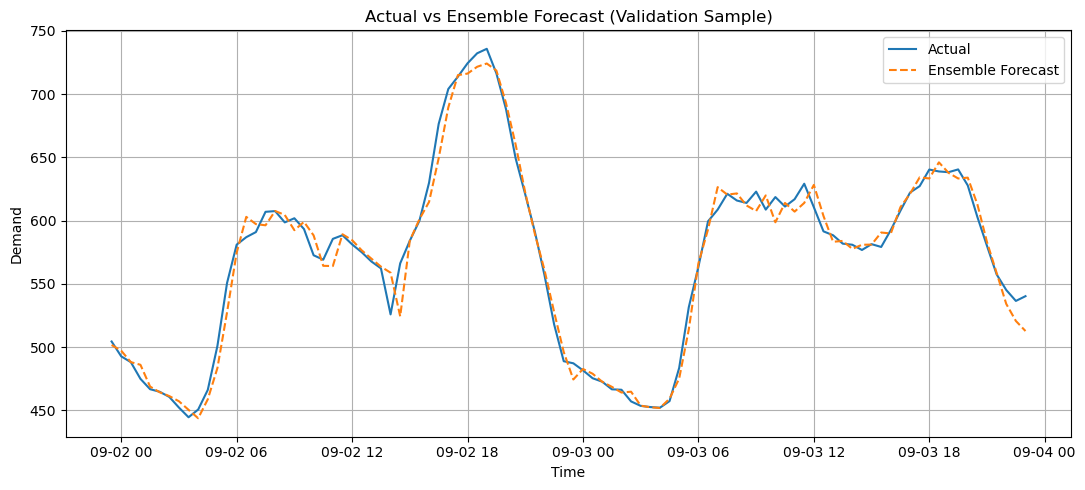

In [36]:
plot_len = 96  # 2 days
t = y_val.index[:plot_len]

plt.figure(figsize=(11,5))
plt.plot(t, y_val.iloc[:plot_len], label="Actual")
plt.plot(t, pred_ens[:plot_len], label="Ensemble Forecast", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Actual vs Ensemble Forecast (Validation Sample)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

`Explanation:` The above code sets up a variable called plot_len with a value of 96, which represents the number of data points to be plotted (equivalent to 2 days of data). It then creates a variable t that extracts the first 96 index values from the y_val DataFrame, which will be used as the x-axis values for the plot.

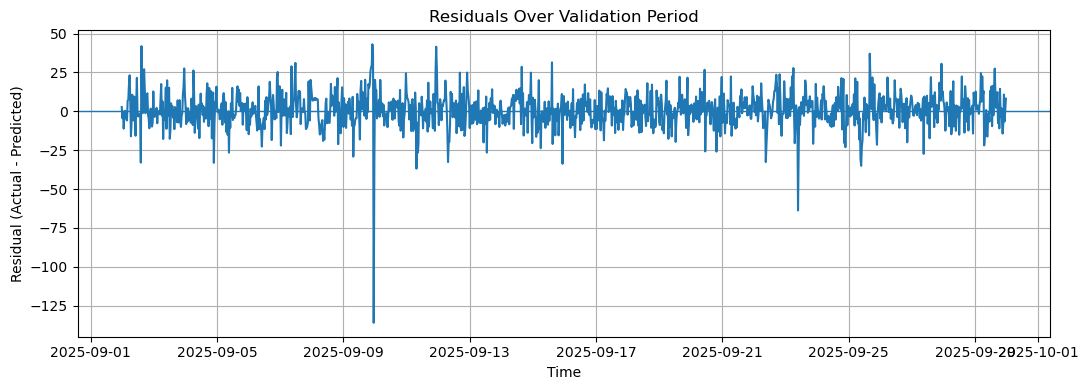

In [37]:
resid = y_val.values - pred_ens

plt.figure(figsize=(11,4))
plt.plot(y_val.index, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Time")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals Over Validation Period")
plt.grid(True)
plt.tight_layout()
plt.show()

`Explanation:` The above code creates a time series plot of residuals (the differences between actual and predicted values). 

1. `resid = y_val.values - pred_ens` - Calculates the residuals by subtracting the predicted values (`pred_ens`) from the actual values (`y_val.values`).

2. `plt.figure(figsize=(11,4))` - Creates a new figure with dimensions of 11 inches wide by 4 inches tall.

3. `plt.plot(y_val.index, resid)` - Plots the residuals over time, using the index of `y_val` (likely timestamps) as the x-axis.

4. `plt.axhline(0, linewidth=1)` - Adds a horizontal line at y=0 to help visualize where predictions match actual values.

5. `plt.xlabel("Time")` and `plt.ylabel("Residual (Actual - Predicted)")` - Adds labels to the x and y axes.

6. `plt.title("Residuals Over Validation Period")` - Adds a title to the plot.

7. `plt.grid(True)` - Adds a grid to the plot for easier reading.

8. `plt.tight_layout()` - Adjusts the plot to ensure everything fits without overlapping.

9. `plt.show()` - Displays the plot.

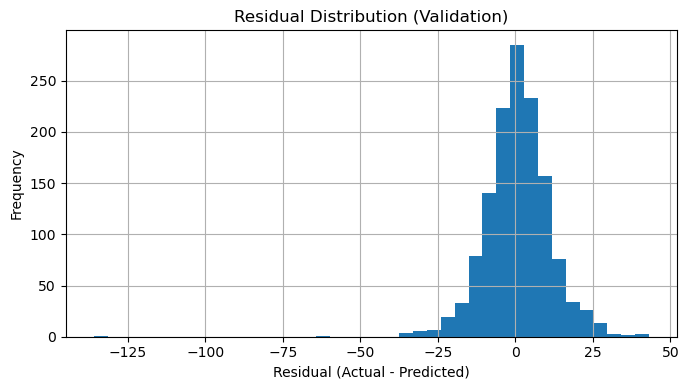

In [38]:
plt.figure(figsize=(7,4))
plt.hist(resid, bins=40)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Validation)")
plt.grid(True)
plt.tight_layout()
plt.show()

`Explanation:` The above code creates and displays a histogram of residuals. 

1. `plt.figure(figsize=(7,4))` - Creates a new figure with a width of 7 inches and height of 4 inches.

2. `plt.hist(resid, bins=40)` - Creates a histogram of the values in the `resid` variable (residuals, which are the differences between actual and predicted values), using 40 bins to group the data.

3. `plt.xlabel("Residual (Actual - Predicted)")` - Adds a label to the x-axis.

4. `plt.ylabel("Frequency")` - Adds a label to the y-axis.

5. `plt.title("Residual Distribution (Validation)")` - Adds a title to the histogram.

6. `plt.grid(True)` - Adds a grid to the plot for better readability.

7. `plt.tight_layout()` - Adjusts the padding between and around subplots to make the plot look better.

8. `plt.show()` - Displays the figure with the histogram.

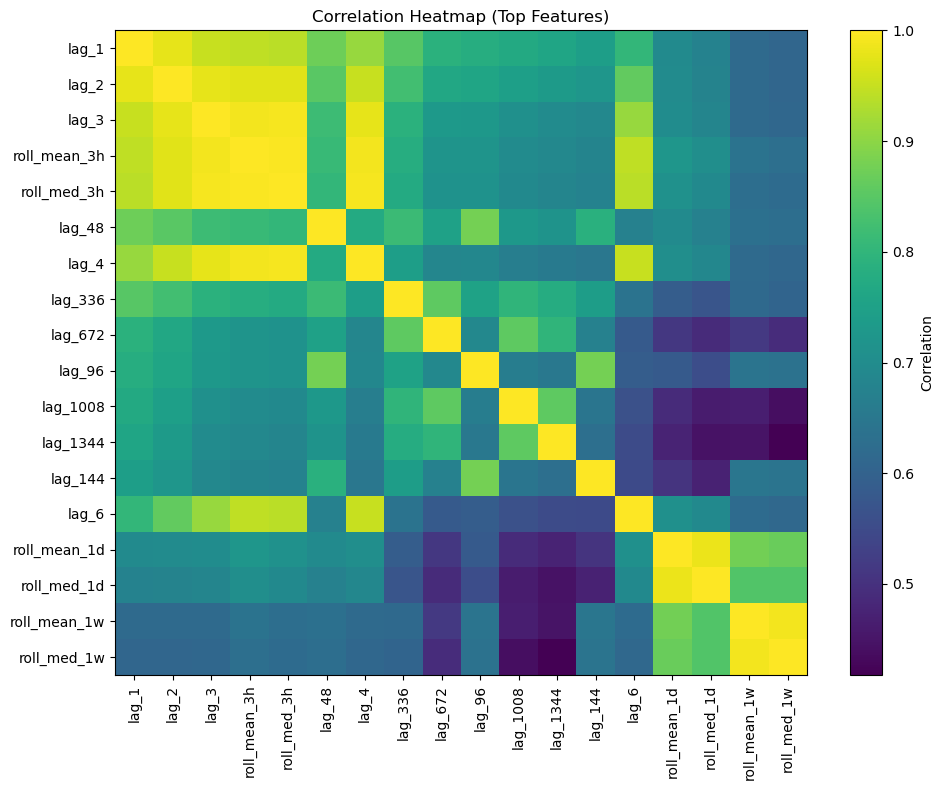

In [39]:
corr = train.assign(demand=y_train).corr(numeric_only=True)
top_cols = corr["demand"].drop("demand").abs().sort_values(ascending=False).head(18).index.tolist()

corr_mat = train[top_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_mat, aspect="auto")
plt.xticks(range(len(top_cols)), top_cols, rotation=90)
plt.yticks(range(len(top_cols)), top_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap (Top Features)")
plt.tight_layout()
plt.show()

`Explanation:` The above code creates a correlation heatmap visualization for the top features most correlated with the target variable "demand". 

1. `corr = train.assign(demand=y_train).corr(numeric_only=True)` - This creates a correlation matrix by first adding the target variable "demand" to the training data, then calculating correlations between all numeric columns.

2. `top_cols = corr["demand"].drop("demand").abs().sort_values(ascending=False).head(18).index.tolist()` - This line:
   - Takes the "demand" column from the correlation matrix
   - Removes the correlation of demand with itself
   - Takes the absolute value of correlations
   - Sorts them in descending order
   - Selects the top 18 features
   - Extracts their names as a list

3. `corr_mat = train[top_cols].corr()` - Calculates the correlation matrix among just these top 18 features.

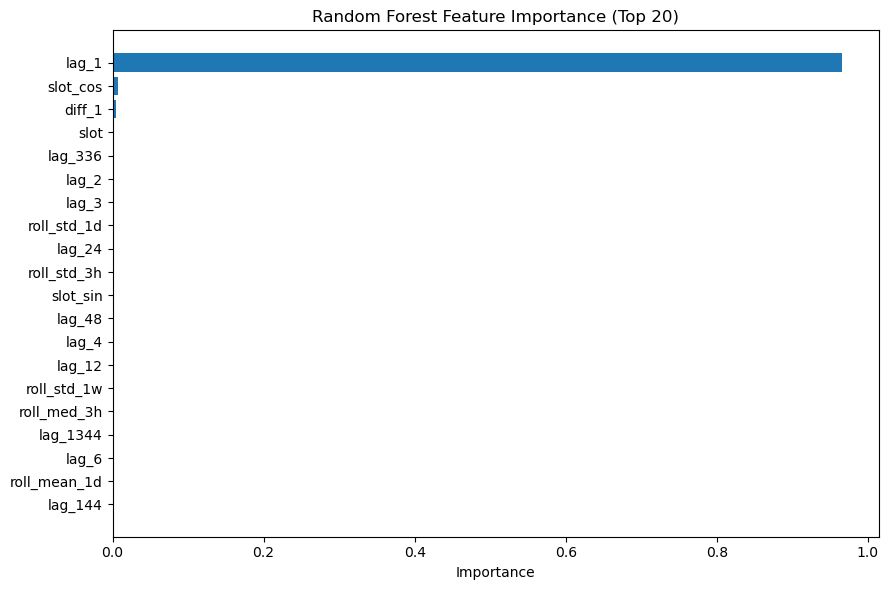

In [40]:
imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(9,6))
plt.barh(imp_rf.index[::-1], imp_rf.values[::-1])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

`Explanation:` The above code creates a horizontal bar chart to visualize the top 20 most important features from a Random Forest model. 

1. `imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)` - This creates a pandas Series containing feature importance scores from a Random Forest model (`rf`), using the column names from `X_train` as the index, sorting them in descending order, and selecting only the top 20 features.

2. `plt.figure(figsize=(9,6))` - Creates a new figure with a width of 9 inches and height of 6 inches.

3. `plt.barh(imp_rf.index[::-1], imp_rf.values[::-1])` - Creates a horizontal bar chart with:
   - The feature names (reversed order) on the y-axis
   - The importance values (reversed order) determining the length of each bar

4. `plt.xlabel("Importance")` - Adds a label to the x-axis.

5. `plt.title("Random Forest Feature Importance (Top 20)")` - Adds a title to the plot.

6. `plt.tight_layout()` - Adjusts the plot to ensure everything fits without overlapping.

7. `plt.show()` - Displays the final visualization.

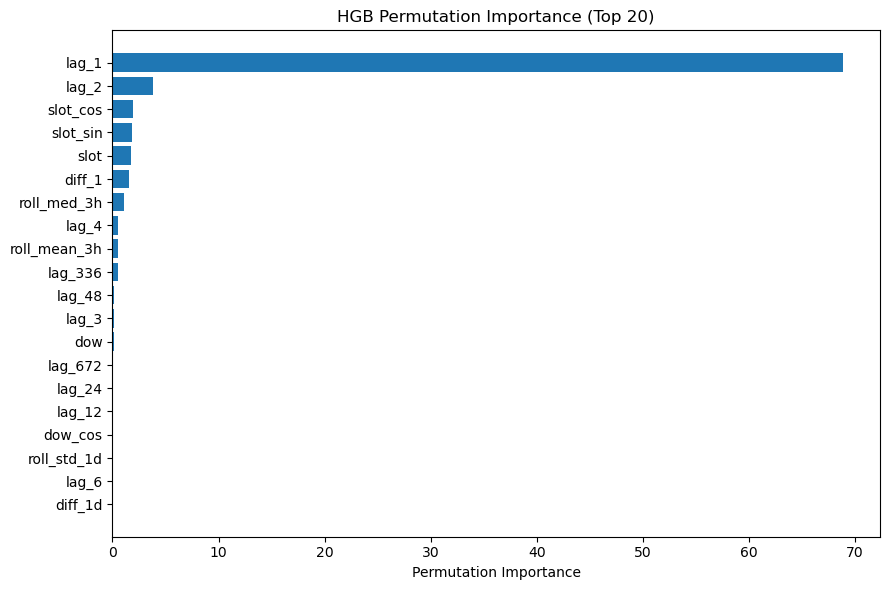

In [41]:
perm = permutation_importance(
    hgb, X_val, y_val,
    n_repeats=5,
    random_state=SEED,
    scoring="neg_root_mean_squared_error"
)

imp_hgb = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(9,6))
plt.barh(imp_hgb.index[::-1], imp_hgb.values[::-1])
plt.xlabel("Permutation Importance")
plt.title("HGB Permutation Importance (Top 20)")
plt.tight_layout()
plt.show()

`Explanation:` The above code calculates and visualizes permutation importance for a Histogram Gradient Boosting model. 
1. `permutation_importance()` calculates feature importance by randomly shuffling each feature's values and measuring how much the model's performance decreases.
   - `hgb`: The trained Histogram Gradient Boosting model
   - `X_val, y_val`: Validation data used to evaluate importance
   - `n_repeats=5`: Performs the permutation process 5 times for more stable results
   - `random_state=SEED`: Sets a random seed for reproducibility
   - `scoring="neg_root_mean_squared_error"`: Uses RMSE as the performance metric

2. The results are converted to a pandas Series with feature names as the index, sorted in descending order, and limited to the top 20 features.

3. A horizontal bar chart is created to visualize these importance values:
   - `[::-1]` reverses the order so the most important features appear at the top
   - The chart includes appropriate labels, title, and layout adjustments

In [42]:
def make_feature_row(history_df, ts):
    base = pd.DataFrame(index=[ts])
    base["demand"] = np.nan

    temp = pd.concat([history_df[["demand"]], base], axis=0)
    temp = add_time_features(temp)
    temp = add_lag_rolling_features(temp, "demand")

    row = temp.iloc[-1].drop(labels=["demand"])
    row = row.reindex(X_train.columns)
    return row

def forecast_steps(df_clean, start_ts, steps=20):
    hist = df_clean.copy()
    preds = []

    for i in range(steps):
        ts = start_ts + pd.Timedelta(minutes=30*i)
        x_row = make_feature_row(hist, ts)

        ph = hgb.predict(pd.DataFrame([x_row]))[0]
        pr = rf.predict(pd.DataFrame([x_row]))[0]
        pl = ridge.predict(pd.DataFrame([x_row]))[0]

        p = w_hgb*ph + w_rf*pr + w_ridge*pl
        preds.append((ts, p))
        hist.loc[ts, "demand"] = p

    return pd.DataFrame(preds, columns=["timestamp", "prediction"])

FORECAST_START = pd.Timestamp("2025-09-30 00:00:00")  
forecast_df = forecast_steps(df, FORECAST_START, steps=20)
forecast_df

,timestamp,prediction
0,2025-09-30 00:00:00,497.457857
1,2025-09-30 00:30:00,494.710784
2,2025-09-30 01:00:00,493.424401
3,2025-09-30 01:30:00,490.255957
4,2025-09-30 02:00:00,488.187036
5,2025-09-30 02:30:00,487.506297
6,2025-09-30 03:00:00,486.963633
7,2025-09-30 03:30:00,486.174867
8,2025-09-30 04:00:00,486.584406
9,2025-09-30 04:30:00,493.512892


`Explanation:` The above code defines two functions for time series forecasting and then uses them to generate predictions. 

1. make_feature_row(history_df, ts) - This function creates a feature row for a specific timestamp:
   - It creates an empty DataFrame with the timestamp as the index
   - Concatenates this with historical data
   - Adds time-based features and lag/rolling features
   - Returns a single row with features aligned to the training data columns

2. forecast_steps(df_clean, start_ts, steps=20) - This function generates multiple forecasts:
   - It makes iterative predictions for a specified number of steps
   - For each step, it creates features using the previous function
   - Makes predictions using three different models (hgb, rf, ridge)
   - Combines these predictions using weights (ensemble approach)
   - Adds each prediction to the history to use for subsequent predictions
   - Returns a DataFrame with timestamps and predictions

3. The last part sets a forecast start time and calls the forecast function:
   - FORECAST_START defines when to begin forecasting (September 30, 2025)
   - forecast_df stores the result of calling forecast_steps for 20 steps ahead
   - The final line displays the forecast results

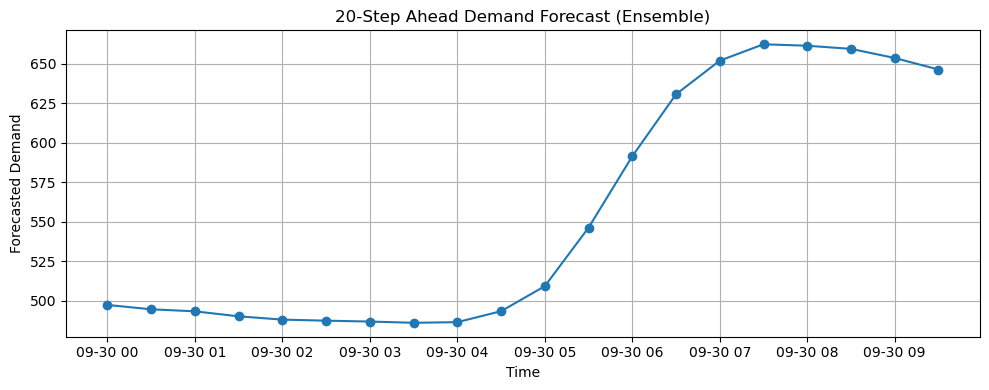

In [43]:
plt.figure(figsize=(10,4))
plt.plot(forecast_df["timestamp"], forecast_df["prediction"], marker="o")
plt.xlabel("Time")
plt.ylabel("Forecasted Demand")
plt.title("20-Step Ahead Demand Forecast (Ensemble)")
plt.grid(True)
plt.tight_layout()
plt.show()

`Explanation:` The above code creates and displays a line plot for forecasted demand data. 

1. `plt.figure(figsize=(10,4))` - Creates a new figure with a width of 10 inches and height of 4 inches.

2. `plt.plot(forecast_df["timestamp"], forecast_df["prediction"], marker="o")` - Plots the data with timestamps on the x-axis and prediction values on the y-axis, using circles as markers at each data point.

3. `plt.xlabel("Time")` - Adds a label to the x-axis.

4. `plt.ylabel("Forecasted Demand")` - Adds a label to the y-axis.

5. `plt.title("20-Step Ahead Demand Forecast (Ensemble)")` - Adds a title to the plot.

6. `plt.grid(True)` - Adds a grid to the plot for better readability.

7. `plt.tight_layout()` - Adjusts the padding between and around subplots to prevent overlapping labels.

8. `plt.show()` - Displays the plot.

In [44]:
forecast_df.to_excel("Manisha_Thakur_474624_predictions.xlsx", index=False)
print("Saved Manisha_Thakur_474624_predictions.xlsx")

Saved Manisha_Thakur_474624_predictions.xlsx


`Explanation:` This code exports data to an Excel file named Manisha_Thakur_474624_predictions and confirms the action. 

1. `forecast_df.to_excel("Manisha_Thakur_474624_predictions.xlsx", index=False)` - This line takes a pandas DataFrame called forecast_df and saves its contents to an Excel file named "Manisha_Thakur_474624_predictions.xlsx". The index=False parameter specifies that the DataFrame's index should not be included in the exported file.

2. `print("Saved Manisha_Thakur_474624_predictions.xlsx")` - This line prints a confirmation message to the console, letting the user know that the Excel file has been successfully saved.